## 01. EDA — ESS 배터리 수명 예측 

**목표**: Batch Data의 EDA 분석 진행
해석, 결론, 모델링 전략은 보고서에 기록

In [15]:
import os, sys, warnings

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore", category=RuntimeWarning)   # 빈 사이클(NaN) 평균 경고 숨김
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
from src.load_data import load_all       # data/cache/b*.pkl 읽기
from src import eda_utils as U           # 피처, knee, 그림 저장 함수
print("작업 폴더:", os.path.basename(os.getcwd()))

작업 폴더: Data_mini


In [16]:
# 자료 기본 설정 (한글 폰트, 격자, 테두리)
mpl.rcParams.update({"font.family": "AppleGothic", "axes.unicode_minus": False, "figure.dpi": 90,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e6e6e3", "grid.linewidth": 0.6, "axes.edgecolor": "#8a8984",
                     "lines.linewidth": 1.2, "figure.constrained_layout.use": True})
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
BC = {"b1": "#2a78d6", "b2": "#eb6834", "b3": "#1baf7a"}          # 배치별 고정 색
BN = {"b1": "Batch1 (2017-05-12)", "b2": "Batch2 (2018-02-20)", "b3": "Batch3 (2018-04-12)"}
# 수명 색 지도: 연한 파랑 = 짧은 수명, 진한 남색 = 긴 수명 (log 스케일 350~2000)
LIFE_CMAP = mpl.colors.LinearSegmentedColormap.from_list("life", ["#c6dbf7", "#2a78d6", "#0b2d5c"])
LIFE_NORM = mpl.colors.LogNorm(350, 2000)
print("자료 저장 폴더:", os.path.relpath(U.FIG_DIR))

자료 저장 폴더: results/figures


### 1. 데이터 load

In [17]:
A = load_all()          
CELLS = {}              
for b in A:
    print(b, "셀 수:", len(A[b]))
    for c in A[b]:
        CELLS[c["cell_id"]] = c
V = A["b1"][0]["Vdlin"]  # Qdlin의 전압 격자 (3.5V → 2.0V, 1,000점, 모든 셀 공통)
print("Qdlin 크기 (사이클 수 x 전압 점 수):", CELLS["b1c0"]["Qdlin"].shape)

b1 셀 수: 46
b2 셀 수: 47
b3 셀 수: 46
Qdlin 크기 (사이클 수 x 전압 점 수): (100, 1000)


In [18]:
df = U.cell_table(A)    # 배치, 정책, cycle_life, 정책 파싱값(C1, Q1, C2), 전처리 플래그
# 셀마다 초기(cycle ≤ 100) 피처와 knee point 
rows = []
for cid, c in CELLS.items():
    end = c["cycle_life"] if np.isfinite(c["cycle_life"]) else None   # 수명이 없으면 곡선 끝까지
    rows.append({"cell_id": cid, **U.early_features(c), **U.knee_point(c["summary"]["QD"], end=end)})
df = df.merge(pd.DataFrame(rows), on="cell_id")
df = df.merge(U.charge_current_table(A), on="cell_id")   # cycle 10 실측 충전 전류 (CSV 캐시)
df["excl"] = U.exclusion_rule(df)      # 제외: cycle_life가 NaN이거나 80%(0.88Ah)까지 안 내려간 셀
df["logL"] = np.log10(df.cycle_life)   # 타깃의 log10
clean = df[~df.excl].copy()            # 모델링에 쓰는 셀
counts = df.groupby("batch").agg(cells=("cell_id", "size"), cycle_life_NaN=("cycle_life_missing", "sum"),
                                 flagged=("flag_any", "sum"), excluded=("excl", "sum"))
counts["clean"] = counts.cells - counts.excluded
print(counts)

       cells  cycle_life_NaN  flagged  excluded  clean
batch                                                 
b1        46               0       11        10     36
b2        47               8        8         8     39
b3        46               2        2         2     44


### 2. 제외 규칙

**2-1** 사이클 번호 규칙, `cycle_life`가 80% 도달 값인지(검열). 제외 규칙 = `cycle_life` NaN 또는 80% 미도달 

In [19]:
# summary['cycle'] 라벨 = 행 번호 + 1 인지, Qdlin 행 0(cycle 1)과 행 9/99(cycle 10/100)가 비었는지
for b in ["b1", "b2", "b3"]:
    label_ok, row0_nan, row_9_99_nan = True, 0, 0
    for c in A[b]:
        cyc = c["summary"]["cycle"]
        if not np.array_equal(cyc, np.arange(1, len(cyc) + 1)):
            label_ok = False
        row0_nan += np.isnan(c["Qdlin"][0]).all()
        row_9_99_nan += np.isnan(c["Qdlin"][[9, 99]]).any()
    print(f"{b}: cycle 라벨 == 행+1 → {label_ok} | Qdlin 행0(cycle 1)이 NaN인 셀 {row0_nan}/{len(A[b])} "
          f"| cycle 10/100 행(9/99) NaN 셀 {row_9_99_nan}")

# cycle_life == 마지막 측정 사이클 + 1 인 셀 수 (Batch1 46셀 모두 → 80% 미도달 셀은 우측 검열)
d = df.dropna(subset=["cycle_life"])
print("\ncycle_life == n_cycles+1 셀 수:", (d.cycle_life == d.n_cycles + 1).groupby(d.batch).sum().to_dict())
print("\nBatch1 80% 미도달 셀 (cycle_life = 시험 종료 시점 → 우측 검열):")
print(df[df.censored_b1][["cell_id", "policy", "cycle_life", "n_cycles", "qd_last"]].to_string(index=False))

b1: cycle 라벨 == 행+1 → True | Qdlin 행0(cycle 1)이 NaN인 셀 46/46 | cycle 10/100 행(9/99) NaN 셀 0
b2: cycle 라벨 == 행+1 → True | Qdlin 행0(cycle 1)이 NaN인 셀 0/47 | cycle 10/100 행(9/99) NaN 셀 0
b3: cycle 라벨 == 행+1 → True | Qdlin 행0(cycle 1)이 NaN인 셀 0/46 | cycle 10/100 행(9/99) NaN 셀 0

cycle_life == n_cycles+1 셀 수: {'b1': 46, 'b2': 0, 'b3': 44}

Batch1 80% 미도달 셀 (cycle_life = 시험 종료 시점 → 우측 검열):
cell_id         policy  cycle_life  n_cycles  qd_last
   b1c0 3.6C(80%)-3.6C      1190.0      1189 1.026210
   b1c1 3.6C(80%)-3.6C      1179.0      1178 1.038225
   b1c2 3.6C(80%)-3.6C      1177.0      1176 1.043279
   b1c3     4C(80%)-4C      1226.0      1225 0.970921
   b1c4     4C(80%)-4C      1227.0      1226 1.021960
   b1c8 5.4C(40%)-3.6C       879.0       878 0.969025
  b1c10   5.4C(50%)-3C       906.0       905 0.961019
  b1c12 5.4C(50%)-3.6C       902.0       901 0.913119
  b1c13 5.4C(50%)-3.6C       897.0       896 0.923136
  b1c22   6C(30%)-3.6C       891.0       890 0.963279


**2-2** Qdlin 손상 행, IR 미측정 셀, Batch1 → Batch2 연장 후보

In [20]:
bad_rows = {}           # Qdlin 손상 행: 한 행의 최대값이 1.3Ah를 넘는 행
for cid, c in CELLS.items():
    rows = np.where(np.nanmax(c["Qdlin"], axis=1) > 1.3)[0].tolist()
    if rows:
        bad_rows[cid] = rows
        assert 9 not in rows and 99 not in rows       # ΔQ에 쓰는 cycle 10/100 행은 정상이어야 함.
print("Qdlin 손상 행(max>1.3Ah) 보유 셀:", len(bad_rows), bad_rows)
ir_zero = []            # IR이 전 구간 0(측정 안 됨)인 셀
for cid, c in CELLS.items():
    if not (c["summary"]["IR"] > 0).any():
        ir_zero.append(cid)
print("\nIR 전 구간 미측정 셀:", ir_zero, "→ 그중 cycle_life 유효:", list(clean[clean.cell_id.isin(ir_zero)].cell_id))
flags = pd.read_csv("data/cache/cell_flags.csv")    # Batch1 → Batch2 연장 후보(전처리 결과)
print("\npreprocess의 연장 후보(정책 일치 + QD/IR 연속) 수:", int(flags.b1_continuation_candidate.sum()))

Qdlin 손상 행(max>1.3Ah) 보유 셀: 18 {'b1c3': [11], 'b1c4': [11], 'b1c20': [12], 'b1c21': [12], 'b1c36': [72], 'b2c2': [46], 'b2c5': [47], 'b2c8': [67], 'b2c10': [46], 'b2c11': [45], 'b2c21': [47], 'b2c22': [36], 'b2c23': [53], 'b2c33': [74], 'b2c35': [63], 'b2c36': [66], 'b2c37': [46], 'b2c45': [68]}

IR 전 구간 미측정 셀: ['b2c40', 'b2c41', 'b2c42', 'b2c43', 'b2c44', 'b2c45', 'b2c46'] → 그중 cycle_life 유효: ['b2c41', 'b2c42', 'b2c43', 'b2c44', 'b2c45', 'b2c46']

preprocess의 연장 후보(정책 일치 + QD/IR 연속) 수: 0


### Q1. 수명 분포

**Q1-1** 배치별 cycle_life 히스토그램 

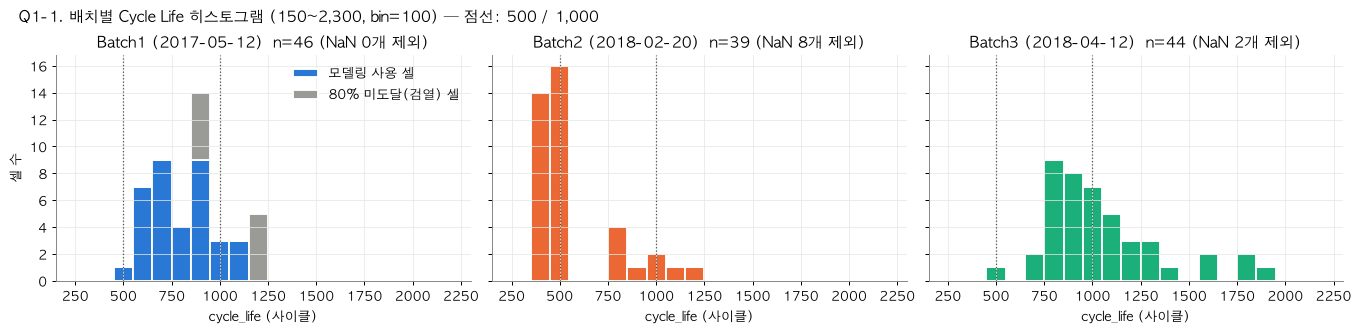

In [22]:
bins = np.arange(150, 2301, 100)                      # 150~2,300, 폭 100
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, b in zip(axes, ["b1", "b2", "b3"]):
    g = df[df.batch == b]
    # 모델링 사용 셀(배치 색)과 Batch1 검열 셀(회색)을 쌓아서 그린다. NaN 셀은 그릴 값 없음
    ax.hist([g[~g.excl].cycle_life, g[g.censored_b1].cycle_life], bins=bins, stacked=True,
            color=[BC[b], "#9a9a96"], edgecolor="white", linewidth=1.5,
            label=["모델링 사용 셀", "80% 미도달(검열) 셀"])
    for x in (500, 1000):                              # 단수명/장수명 기준선
        ax.axvline(x, color="#52514e", ls=":", lw=1)
    ax.set_title(f"{BN[b]}  n={g.cycle_life.notna().sum()} (NaN {g.cycle_life.isna().sum()}개 제외)")
    ax.set_xlabel("cycle_life (사이클)")
    ax.set_xlim(150, 2300)
axes[0].set_ylabel("셀 수")
axes[0].legend(frameon=False)
fig.suptitle("Q1-1. 배치별 Cycle Life 히스토그램 (150~2,300, bin=100) — 점선: 500 / 1,000", x=0.01, ha="left")
U.savefig(fig, "Q1_1_cycle_life_hist.png")
plt.show()

**Q1-2** 배치별 요약 통계, 장수명(>1000)/단수명(<500) 비율, 제외 전/후

In [23]:
# 배치별 요약 통계: 제외 전과 제외 후를 비교
rows = []
for tag, frame in [("전체(타깃 있는 셀)", df), ("제외규칙 적용", clean)]:
    for b, g in frame.groupby("batch"):
        cl = g.cycle_life.dropna()
        rows.append({"batch": b, "set": tag, "n": len(cl), "mean": cl.mean(), "median": cl.median(),
                     "std": cl.std(), "min": cl.min(), "max": cl.max(),
                     "skew": stats.skew(cl), "skew(log10)": stats.skew(np.log10(cl)),   
                     "long>1000": (cl > 1000).sum(), "short<500": (cl < 500).sum(),
                     "long%": 100 * (cl > 1000).mean(), "short%": 100 * (cl < 500).mean()})
q1 = pd.DataFrame(rows).sort_values(["batch", "set"])
print(q1.round(2).to_string(index=False))

batch         set  n    mean  median    std   min    max  skew  skew(log10)  long>1000  short<500  long%  short%
   b1 전체(타깃 있는 셀) 46  844.72   858.5 184.63 534.0 1227.0  0.44         0.04         10          0  21.74    0.00
   b1     제외규칙 적용 36  788.42   772.5 148.70 534.0 1074.0  0.29        -0.01          5          0  13.89    0.00
   b2 전체(타깃 있는 셀) 39  565.74   472.0 222.20 392.0 1186.0  1.57         1.30          3         28   7.69   71.79
   b2     제외규칙 적용 39  565.74   472.0 222.20 392.0 1186.0  1.57         1.30          3         28   7.69   71.79
   b3 전체(타깃 있는 셀) 44 1059.66  1005.5 313.87 541.0 1935.0  1.21         0.50         23          0  52.27    0.00
   b3     제외규칙 적용 44 1059.66  1005.5 313.87 541.0 1935.0  1.21         0.50         23          0  52.27    0.00


**Q1-3** 3배치 통합 왜도: 원값 vs log10

In [24]:
sk_all = (stats.skew(clean.cycle_life), stats.skew(clean.logL))      # 3배치 통합 왜도
print("통합 skew raw / log10:", np.round(sk_all, 3))

통합 skew raw / log10: [1.036 0.034]


**Q1-4** 이상치(로그 IQR 펜스), 배치별 하위 10% 셀, Batch2 newstructure 여부별 수명

In [26]:
rows = []               # 이상치: 배치 안 log10(cycle_life)에 IQR 펜스(Q1 − 1.5·IQR, Q3 + 1.5·IQR)
for b, g in clean.groupby("batch"):
    q1_, q3_ = np.percentile(g.logL, [25, 75])
    lo = 10 ** (q1_ - 1.5 * (q3_ - q1_))                 # 로그에서 구한 펜스를 원래 단위로 되돌림
    hi = 10 ** (q3_ + 1.5 * (q3_ - q1_))
    print(f"{b}: IQR 펜스(로그) [{lo:.0f}, {hi:.0f}] → 하한 밖 {list(g[g.cycle_life < lo].cell_id)}, "
          f"상한 밖 {list(g[g.cycle_life > hi].cell_id)}")
    rows.append(g[g.cycle_life <= g.cycle_life.quantile(0.10)])     # 배치 안 하위 10% 셀

cols = ["cycle_life", "C1", "Q1", "C2", "avgC_0to80_meas", "dQ_log_var"]
print("\n배치별 하위 10% 셀:")
print(pd.concat(rows)[["cell_id", "policy"] + cols].round(3).to_string(index=False))
b2 = df[(df.batch == "b2") & df.cycle_life.notna()]
print("\nBatch2 'newstructure' 여부별 cycle_life:")
print(b2.groupby("newstructure").cycle_life.describe().round(0))

b1: IQR 펜스(로그) [470, 1262] → 하한 밖 [], 상한 밖 []
b2: IQR 펜스(로그) [353, 633] → 하한 밖 [], 상한 밖 ['b2c7', 'b2c8', 'b2c9', 'b2c32', 'b2c33', 'b2c34', 'b2c43', 'b2c44', 'b2c45']
b3: IQR 펜스(로그) [502, 1904] → 하한 밖 [], 상한 밖 ['b3c38']

배치별 하위 10% 셀:
cell_id                      policy  cycle_life  C1   Q1  C2  avgC_0to80_meas  dQ_log_var
  b1c20              5.4C(80%)-5.4C       534.0 5.4 80.0 5.4            5.392      -3.367
  b1c21              5.4C(80%)-5.4C       559.0 5.4 80.0 5.4            5.396      -3.350
  b1c44                8C(35%)-3.6C       616.0 8.0 35.0 3.6            4.735      -3.421
  b1c45                8C(35%)-3.6C       599.0 8.0 35.0 3.6            4.735      -3.425
   b2c6                 3.6C(9%)-5C       393.0 3.6  9.0 5.0            4.795      -3.530
  b2c15                 3.6C(9%)-5C       396.0 3.6  9.0 5.0            4.797      -3.516
  b2c19                  6C(60%)-3C       392.0 6.0 60.0 3.0            4.797      -3.292
  b2c21                  6C(60%)-3C       408

**Q1-5** 과제 분류 기준(550) 라벨 분포, 학습(b1) 수명 범위 밖 테스트 셀 수

In [27]:
# Classification 라벨(cycle_life >= 550 → 1, 미만 → 0). acc_all1% = 전부 1로 찍었을 때 정확도
lab = clean.assign(label=(clean.cycle_life >= 550).astype(int))
t = lab.groupby("batch").label.agg(n="size", long_1="sum")
t["short_0"] = t.n - t.long_1
t["short%"] = (100 * t.short_0 / t.n).round(1)
t["acc_all1%"] = (100 * t.long_1 / t.n).round(1)
print(t)
tr = clean[clean.batch == "b1"].cycle_life
for b in ["b2", "b3"]:
    g = clean[clean.batch == b].cycle_life
    print(f"{b}: 학습(b1, {tr.min():.0f}~{tr.max():.0f}) 범위 밖 셀 — 아래 {int((g < tr.min()).sum())}개, "
          f"위 {int((g > tr.max()).sum())}개 / {len(g)}")

        n  long_1  short_0  short%  acc_all1%
batch                                        
b1     36      35        1     2.8       97.2
b2     39       9       30    76.9       23.1
b3     44      43        1     2.3       97.7
b2: 학습(b1, 534~1074) 범위 밖 셀 — 아래 30개, 위 2개 / 39
b3: 학습(b1, 534~1074) 범위 밖 셀 — 아래 0개, 위 16개 / 44


### Q2. 열화 곡선과 knee point

**Q2-1** knee point 예시(배치별 중앙값 수명 셀)와 knee/수명 분포 

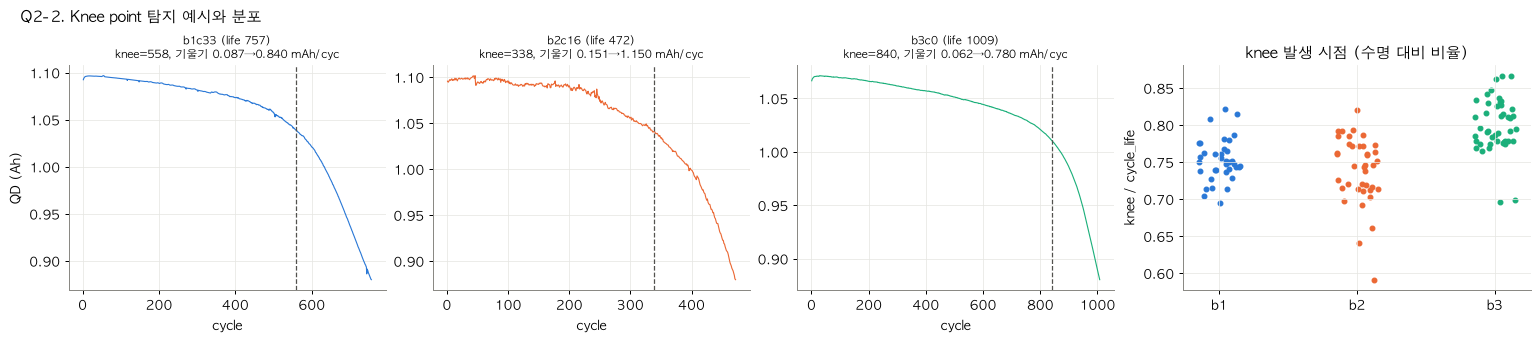

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.7), gridspec_kw={"width_ratios": [1, 1, 1, 1.1]})
# 왼쪽 세 칸: 배치마다 수명이 중앙값에 가장 가까운 셀 1개
for ax, b in zip(axes[:3], ["b1", "b2", "b3"]):
    g = clean[clean.batch == b]
    r = g.iloc[(g.cycle_life - g.cycle_life.median()).abs().argsort().iloc[0]]
    q = U.clean_qd(CELLS[r.cell_id]["summary"]["QD"])[: int(r.cycle_life)]   # EOL까지만
    ax.plot(np.arange(1, len(q) + 1), q, color=BC[b], lw=0.9)
    ax.axvline(r.knee, color="#52514e", ls="--", lw=1)
    ax.set_title(f"{r.cell_id} (life {r.cycle_life:.0f})\nknee={r.knee:.0f}, "
                 f"기울기 {r.rate_pre*1e3:.3f}→{r.rate_post*1e3:.3f} mAh/cyc", fontsize=9)
    ax.set_xlabel("cycle")
axes[0].set_ylabel("QD (Ah)")

# 오른쪽: knee가 수명의 몇 % 지점에 오는지 (모든 사용 셀, 점이 겹치지 않게 좌우로 분포)
clean["knee_frac"] = clean.knee / clean.cycle_life
for i, b in enumerate(["b1", "b2", "b3"]):
    v = clean[clean.batch == b].knee_frac
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(v))
    axes[3].scatter(np.full(len(v), i) + jitter, v, s=14, color=BC[b])
axes[3].set_xticks([0, 1, 2], ["b1", "b2", "b3"])
axes[3].set_ylabel("knee / cycle_life")
axes[3].set_title("knee 발생 시점 (수명 대비 비율)")
fig.suptitle("Q2-2. Knee point 탐지 예시와 분포", x=0.01, ha="left")
U.savefig(fig, "Q2_2_knee_point.png")
plt.show()

**Q2-2** 배치별 knee 시점, knee 앞/뒤 감소 속도(mAh/cycle)와 가속 배율

In [31]:
# 배치별 중앙값 요약. 기울기는 mAh/cycle, accel = knee 뒤 기울기 / knee 앞 기울기 (가속 배율)
clean["accel"] = clean.rate_post / clean.rate_pre
by = clean.groupby("batch")
q2 = by.agg(knee_median=("knee", "median"), knee_frac_median=("knee_frac", "median"),
            knee_frac_min=("knee_frac", "min"), knee_frac_max=("knee_frac", "max"))
q2["fade_pre_mAh"] = 1e3 * by.rate_pre.median()
q2["fade_post_mAh"] = 1e3 * by.rate_post.median()
q2["accel_median"] = by.accel.median()
for b, g in by:
    q2.loc[b, "rho(knee, life)"] = stats.spearmanr(g.knee, g.cycle_life)[0]
print(q2.round(3))

       knee_median  knee_frac_median  knee_frac_min  knee_frac_max  fade_pre_mAh  fade_post_mAh  accel_median  rho(knee, life)
batch                                                                                                                         
b1           577.0             0.750          0.695          0.821         0.072          0.793        10.496            0.981
b2           342.0             0.746          0.591          0.820         0.103          1.327        11.290            0.937
b3           819.0             0.794          0.696          0.867         0.061          0.683         9.976            0.979


**Q2-3** 초기 100사이클 용량 변화(cycle 2 → 100)와 EOL까지 총 손실

In [32]:
# 초기 100사이클 동안 용량은 얼마나 줄었나? (EOL까지 총 감소량과 비교, 양수 = 감소)
clean["loss_c2_to_c100_mAh"] = -1e3 * clean.QD_c100_minus_c2
clean["loss_c2_to_EOL_mAh"] = 1e3 * (clean.QD_c2 - U.EOL_AH)
loss = clean.groupby("batch")[["loss_c2_to_c100_mAh", "loss_c2_to_EOL_mAh"]].median().round(1)
loss["초기100사이클 손실 비중%"] = (100 * loss.loss_c2_to_c100_mAh / loss.loss_c2_to_EOL_mAh).round(1)
print(loss)

       loss_c2_to_c100_mAh  loss_c2_to_EOL_mAh  초기100사이클 손실 비중%
batch                                                          
b1                    -2.4               198.4             -1.2
b2                    -2.2               215.4             -1.0
b3                    -1.4               185.3             -0.8


**Q2-4** 초기 용량 변화 vs 수명 Spearman ρ

In [33]:
rho_early = {}
for b, g in clean.groupby("batch"):
    rho_early[b] = round(float(stats.spearmanr(g.QD_c100_minus_c2, g.cycle_life)[0]), 2)
print("Spearman(QD_c100-QD_c2, life):", rho_early)

Spearman(QD_c100-QD_c2, life): {'b1': 0.42, 'b2': -0.1, 'b3': -0.14}


### Q3. ΔQ(V) 곡선

**Q3-1** cycle 10 Q(2.0V) 배치 중앙값, 2.0~2.8V 배치 간 최대 차이: 원값 vs Q(2.0V) 정규화

In [34]:
# 배치마다 셀별 cycle 10 방전 곡선 Q10(V)의 중앙값: 원값과 셀별 Q(2.0V)로 나눈 정규화 곡선
med_raw, med_norm = {}, {}
for b in ["b1", "b2", "b3"]:
    q10 = np.array([c["Qdlin"][9] for c in A[b]], dtype=float)
    med_raw[b] = np.nanmedian(q10, axis=0)
    med_norm[b] = np.nanmedian(q10 / q10[:, [-1]], axis=0)
    print(f"{b}  cycle 10 Q(2.0V) 중앙값 {med_raw[b][-1]:.4f} Ah")
raw = np.array([med_raw["b1"], med_raw["b2"], med_raw["b3"]])
norm = np.array([med_norm["b1"], med_norm["b2"], med_norm["b3"]])
gap_raw = raw.max(axis=0) - raw.min(axis=0)    # 전압 점마다 가장 높은 배치 − 가장 낮은 배치
gap_norm = norm.max(axis=0) - norm.min(axis=0)
low = V <= 2.8          # 평탄 구간(2.0~2.8V)
print(f"2.0~2.8V 구간 배치 중앙값 곡선 최대 차이: 원값 {gap_raw[low].max()*1e3:.1f} mAh → 정규화 후 {gap_norm[low].max()*100:.2f} %")
print(f"전체 전압 구간 최대 차이: 원값 {gap_raw.max()*1e3:.1f} mAh / 정규화 {gap_norm.max()*100:.2f} %")

b1  cycle 10 Q(2.0V) 중앙값 1.0669 Ah
b2  cycle 10 Q(2.0V) 중앙값 1.0599 Ah
b3  cycle 10 Q(2.0V) 중앙값 1.0525 Ah
2.0~2.8V 구간 배치 중앙값 곡선 최대 차이: 원값 14.4 mAh → 정규화 후 0.41 %
전체 전압 구간 최대 차이: 원값 27.1 mAh / 정규화 3.17 %


**Q3-2** ΔQ100-10(V) 곡선, 배치 안 장수명(상위 25%) vs 단수명(하위 25%) 평균 최저점 

b1 장수명(상위25%, ≥872): 평균 곡선 최저점 -30.5 mAh @ 2.93 V
b1 단수명(하위25%, ≤681): 평균 곡선 최저점 -53.1 mAh @ 2.95 V
b2 장수명(상위25%, ≥508): 평균 곡선 최저점 -24.5 mAh @ 2.91 V
b2 단수명(하위25%, ≤440): 평균 곡선 최저점 -64.6 mAh @ 2.95 V
b3 장수명(상위25%, ≥1155): 평균 곡선 최저점 -14.8 mAh @ 2.87 V
b3 단수명(하위25%, ≤828): 평균 곡선 최저점 -33.2 mAh @ 2.92 V


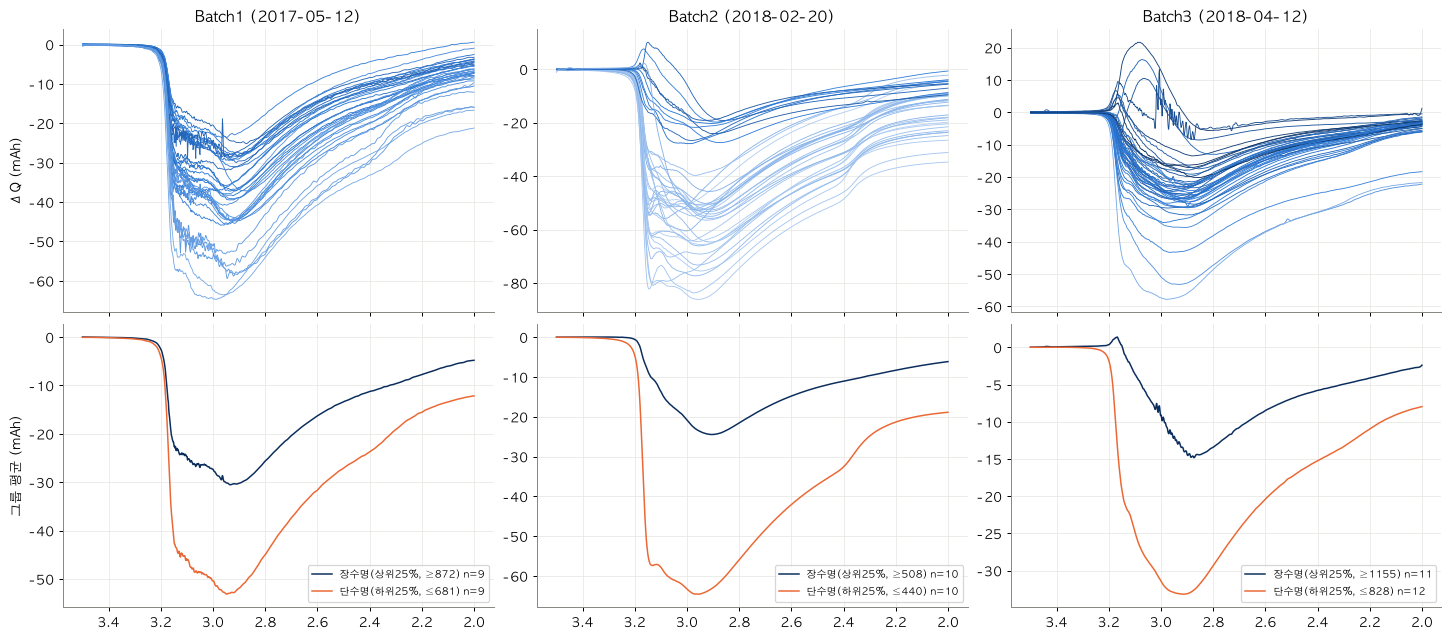

In [52]:
# 위: 셀별 ΔQ = Q100(V) − Q10(V) (색 = 수명) / 아래: 배치 안 수명 상위·하위 25% 평균 곡선
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
for j, b in enumerate(["b1", "b2", "b3"]):
    g = clean[clean.batch == b]
    lo, hi = g.cycle_life.quantile([0.25, 0.75])                  # 하위/상위 25% 경계
    dq = {cid: U.delta_q(CELLS[cid]) * 1e3 for cid in g.cell_id}   # 셀별 ΔQ (mAh)
    for cid, life in zip(g.cell_id, g.cycle_life):
        axes[0, j].plot(V, dq[cid], color=LIFE_CMAP(LIFE_NORM(life)), lw=0.7)
    for sel, col, lab in ((g.cycle_life >= hi, "#0b2d5c", f"장수명(상위25%, ≥{hi:.0f})"),
                          (g.cycle_life <= lo, "#eb6834", f"단수명(하위25%, ≤{lo:.0f})")):
        m = np.mean([dq[c] for c in g[sel].cell_id], axis=0)       # 그룹 평균 곡선
        axes[1, j].plot(V, m, color=col, label=f"{lab} n={sel.sum()}")
        print(f"{b} {lab}: 평균 곡선 최저점 {m.min():.1f} mAh @ {V[m.argmin()]:.2f} V")
    axes[0, j].set_title(BN[b])
    axes[1, j].legend(fontsize=8)
axes[0, 0].invert_xaxis()            # sharex: 한 번만 뒤집으면 전부 뒤집힘
axes[0, 0].set_ylabel("ΔQ (mAh)")
axes[1, 0].set_ylabel("그룹 평균 (mAh)")
U.savefig(fig, "Q3_1_deltaQ_curves.png")
plt.show()


**Q3-3** ΔQ 통계 피처 5개(log10 분산, log10 |최소|, log10 |평균|, 왜도, 첨도) vs 배치 안 log10 수명 Pearson r

In [37]:
dq_feats = ["dQ_log_var", "dQ_log_abs_min", "dQ_log_abs_mean", "dQ_skew", "dQ_kurt"]
r_dq = {}
for b, g in clean.groupby("batch"):
    r_dq[b] = [stats.pearsonr(g[f], g.logL)[0] for f in dq_feats]
print(pd.DataFrame(r_dq, index=dq_feats).round(3))

                    b1     b2     b3
dQ_log_var      -0.844 -0.918 -0.762
dQ_log_abs_min  -0.821 -0.901 -0.744
dQ_log_abs_mean -0.771 -0.874 -0.648
dQ_skew         -0.434 -0.126  0.188
dQ_kurt          0.022  0.653  0.341


**Q3-4** ΔQ 돌출 셀(max ΔQ > +2mAh)과 제외 시 상관 변화, 통합 r, Batch2 무리 안 r

In [39]:
bump = []               # max ΔQ > +2mAh = 3.0~3.2V 부근에서 곡선이 위로 튀어나온 셀
for cid, c in CELLS.items():
    if np.max(U.delta_q(c)) > 0.002:
        bump.append(cid)
print("max ΔQ > +2mAh 셀:")
for b in ["b1", "b2", "b3"]:
    print(" ", b, sorted(df[(df.batch == b) & df.cell_id.isin(bump)].cell_id))

# 돌출 셀을 뺐을 때 배치 안 상관 변화 
for b in ["b2", "b3"]:
    g = clean[clean.batch == b]
    g_wo = g[~g.cell_id.isin(bump)]
    print(f"{b} 모델링 셀 중 돌출 셀 {sorted(g[g.cell_id.isin(bump)].cell_id)}")
    print(f"   dQ_log_var: r 전체 {stats.pearsonr(g.dQ_log_var, g.logL)[0]:.3f} (n={len(g)}) "
          f"→ 돌출 셀 제외 {stats.pearsonr(g_wo.dQ_log_var, g_wo.logL)[0]:.3f} (n={len(g_wo)})")
print("통합(3배치) Pearson r dQ_log_var vs log10 life: %.3f" % stats.pearsonr(clean.dQ_log_var, clean.logL)[0])
g2 = clean[clean.batch == "b2"]
for ns, h in g2.groupby("newstructure"):
    print(f"b2 {'newstructure' if ns else '기존 구조'} {len(h)}셀: dQ_log_var r = {stats.pearsonr(h.dQ_log_var, h.logL)[0]:.3f}")
print(f"b2 전체 Spearman ρ(dQ_log_var, logL) = {stats.spearmanr(g2.dQ_log_var, g2.logL)[0]:.3f}")

max ΔQ > +2mAh 셀:
  b1 []
  b2 ['b2c22', 'b2c33', 'b2c43', 'b2c46', 'b2c9']
  b3 ['b3c16', 'b3c17', 'b3c2', 'b3c23', 'b3c32', 'b3c37', 'b3c38', 'b3c39', 'b3c42', 'b3c43']
b2 모델링 셀 중 돌출 셀 ['b2c33', 'b2c43', 'b2c46', 'b2c9']
   dQ_log_var: r 전체 -0.918 (n=39) → 돌출 셀 제외 -0.907 (n=35)
b3 모델링 셀 중 돌출 셀 ['b3c16', 'b3c17', 'b3c2', 'b3c37', 'b3c38', 'b3c39', 'b3c42', 'b3c43']
   dQ_log_var: r 전체 -0.762 (n=44) → 돌출 셀 제외 -0.795 (n=36)
통합(3배치) Pearson r dQ_log_var vs log10 life: -0.897
b2 기존 구조 30셀: dQ_log_var r = -0.375
b2 newstructure 9셀: dQ_log_var r = -0.266
b2 전체 Spearman ρ(dQ_log_var, logL) = -0.709


**Q3-5** 인덱싱 민감도: cycle 라벨 10/100(행 9/99) vs 0-기준 행 10/100의 log10 Var(ΔQ)

In [41]:
alt = []                
for cid in clean.cell_id:
    c = CELLS[cid]
    q100 = U.read_qdlin_row(c["batch"], c["index"], 100)
    alt.append(np.log10(np.var(q100 - c["Qdlin"][10].astype(float))))
clean["dQ_log_var_alt"] = alt
print("두 정의 간 Pearson r: %.4f" % stats.pearsonr(clean.dQ_log_var, clean.dQ_log_var_alt)[0])

두 정의 간 Pearson r: 0.9846


### Q4. 충전 조건(C-rate)과 수명

**Q4-1** 정책 문자열로 계산한 평균 C-rate vs cycle 10 실측 평균 C-rate 불일치 셀

In [42]:
# 정책 문자열로 계산한 평균 C-rate vs 실제로 잰 평균 C-rate: 0.1C 넘게 다른 셀
d = df.dropna(subset=["avg_C_0to80"])
mis = d[(d.avg_C_0to80 - d.avgC_0to80_meas).abs() > 0.1]
print("정책 파싱 평균 C-rate vs 측정 평균 C-rate 불일치(>0.1C) 셀:", len(mis))
print(mis[["cell_id", "policy", "avg_C_0to80", "avgC_0to80_meas", "I_peak_C", "t_to80_min", "cycle_life"]].round(2).to_string(index=False))

정책 파싱 평균 C-rate vs 측정 평균 C-rate 불일치(>0.1C) 셀: 8
cell_id                      policy  avg_C_0to80  avgC_0to80_meas  I_peak_C  t_to80_min  cycle_life
   b3c7 4.8C(80%)-4.8C-newstructure          4.8             4.36      4.37       11.00      1836.0
  b3c10 4.8C(80%)-4.8C-newstructure          4.8             4.36      4.37       11.00      1078.0
  b3c16 4.8C(80%)-4.8C-newstructure          4.8             4.36      4.37       11.01      1638.0
  b3c23 4.8C(80%)-4.8C-newstructure          4.8             4.36      4.37       11.00         NaN
  b3c32 4.8C(80%)-4.8C-newstructure          4.8             4.36      4.37       11.00         NaN
  b3c37 4.8C(80%)-4.8C-newstructure          4.8             4.36      4.37       11.00      1390.0
  b3c42 4.8C(80%)-4.8C-newstructure          4.8             4.36      4.37       11.00      1642.0
  b3c45 4.8C(80%)-4.8C-newstructure          4.8             4.36      4.37       11.00      1801.0


**Q4-2** 충전 프로토콜별 평균 수명 

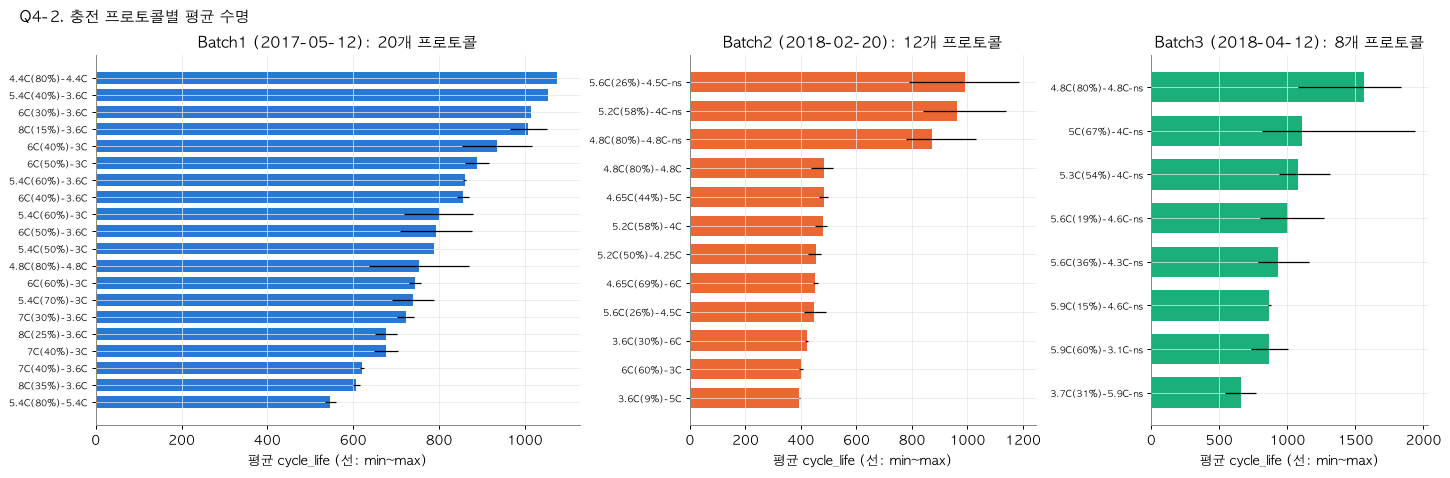

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1.4, 1, 0.8]})
for ax, b in zip(axes, ["b1", "b2", "b3"]):
    # 프로토콜별 평균, 셀 수, 최소/최대 수명, 평균 수명 순으로 정렬
    g = clean[clean.batch == b].groupby("policy").agg(life=("cycle_life", "mean"), n=("cycle_life", "size"),
                                                       lo=("cycle_life", "min"), hi=("cycle_life", "max"))
    g = g.sort_values("life")
    y = np.arange(len(g))
    ax.barh(y, g.life, color=BC[b], height=0.7)
    ax.hlines(y, g.lo, g.hi, color="black", lw=1)       # 가로선 = 최소~최대
    ax.set_yticks(y, [p.replace("-newstructure", "-ns") for p in g.index], fontsize=7.5)
    ax.set_xlabel("평균 cycle_life (선: min~max)")
    ax.set_title(f"{BN[b]}: {len(g)}개 프로토콜")
fig.suptitle("Q4-2. 충전 프로토콜별 평균 수명", x=0.01, ha="left")
U.savefig(fig, "Q4_2_life_by_protocol.png")
plt.show()

**Q4-3** Batch1 프로토콜 η², 프로토콜별 평균 수명 최고/최저, Batch1 프로토콜을 쓴 Batch2/3 셀 수

In [45]:
# η² = 프로토콜이 설명하는 log10 수명 분산의 비율 = 1 − (그룹 안 제곱합 / 전체 제곱합)
b1c = clean[clean.batch == "b1"]
within = b1c.logL - b1c.groupby("policy").logL.transform("mean")     # 각 셀 − 자기 프로토콜 평균
eta2 = 1 - (within ** 2).sum() / ((b1c.logL - b1c.logL.mean()) ** 2).sum()
print(f"Batch1 프로토콜이 설명하는 log10 수명 분산 비율(η²): {eta2:.2f}  (프로토콜 {b1c.policy.nunique()}개, 셀 {len(b1c)}개)")
pm = b1c.groupby("policy").cycle_life.mean().sort_values()
print(f"Batch1 프로토콜 평균 수명: 최고 {pm.index[-1]} {pm.iloc[-1]:.0f} / 최저 {pm.index[0]} {pm.iloc[0]:.0f}")
print("배치별 프로토콜 수:", clean.groupby("batch").policy.nunique().to_dict())
for b in ["b2", "b3"]:      # Batch2/3 셀 중 Batch1에 있는 프로토콜을 쓴 셀 수
    seen = clean[clean.batch == b].policy.isin(b1c.policy).sum()
    print(f"{b}: Batch1(학습)에 존재하는 프로토콜을 쓴 셀 {seen}/{(clean.batch == b).sum()}")

Batch1 프로토콜이 설명하는 log10 수명 분산 비율(η²): 0.89  (프로토콜 20개, 셀 36개)
Batch1 프로토콜 평균 수명: 최고 4.4C(80%)-4.4C 1074 / 최저 5.4C(80%)-5.4C 546
배치별 프로토콜 수: {'b1': 20, 'b2': 12, 'b3': 8}
b2: Batch1(학습)에 존재하는 프로토콜을 쓴 셀 7/39
b3: Batch1(학습)에 존재하는 프로토콜을 쓴 셀 0/44


**Q4-4** 실측 평균 C-rate(0→80%)·피크 C-rate vs 수명

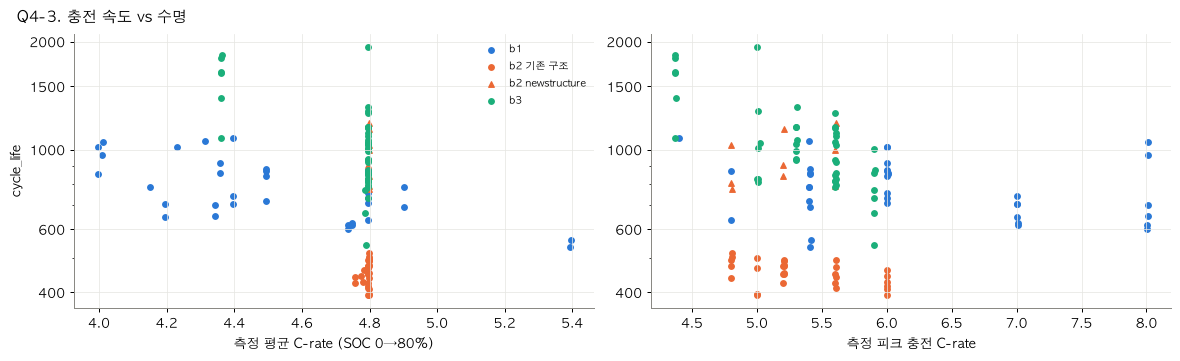

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))
for b in ["b1", "b2", "b3"]:
    g = clean[clean.batch == b]
    parts = [(g, "o", b)]
    if b == "b2":       # Batch2는 기존 구조(●)와 newstructure(▲)를 다른 모양으로 구분
        parts = [(g[~g.newstructure], "o", "b2 기존 구조"), (g[g.newstructure], "^", "b2 newstructure")]
    for h, mk, lab in parts:
        axes[0].scatter(h.avgC_0to80_meas, h.cycle_life, s=20, marker=mk, color=BC[b], label=lab)
        axes[1].scatter(h.I_peak_C, h.cycle_life, s=20, marker=mk, color=BC[b], label=lab)
axes[0].set_xlabel("측정 평균 C-rate (SOC 0→80%)")
axes[1].set_xlabel("측정 피크 충전 C-rate")
for ax in axes:
    ax.set_yscale("log")
    ax.set_yticks([400, 600, 1000, 1500, 2000], ["400", "600", "1000", "1500", "2000"])
axes[0].set_ylabel("cycle_life")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Q4-3. 충전 속도 vs 수명", x=0.01, ha="left")
U.savefig(fig, "Q4_3_crate_vs_life.png")
plt.show()

**Q4-5** 실측 평균 C-rate vs 수명 평균 열화속도 Spearman ρ, Batch2 기존 구조 vs newstructure 중앙값

In [51]:
clean["fade_life"] = 1e3 * (clean.QD_c2 - U.EOL_AH) / clean.cycle_life    # mAh/cycle, EDA 전용 (타깃 사용)
rho_fade = {}
for b, g in clean.groupby("batch"):
    rho_fade[b] = round(float(stats.spearmanr(g.avgC_0to80_meas, g.fade_life)[0]), 2)
print("Spearman(avgC_0to80_meas, fade_life):", rho_fade)
print("\nBatch2 기존구조 vs newstructure 중앙값:")
print(clean[clean.batch == "b2"].groupby("newstructure")[["cycle_life", "avgC_0to80_meas", "fade_life", "dQ_log_var", "chargetime_mean_2_6"]].median().round(3))

Spearman(avgC_0to80_meas, fade_life): {'b1': 0.51, 'b2': -0.52, 'b3': 0.21}

Batch2 기존구조 vs newstructure 중앙값:
              cycle_life  avgC_0to80_meas  fade_life  dQ_log_var  chargetime_mean_2_6
newstructure                                                                         
False              451.0            4.797      0.471      -3.456               10.175
True               904.0            4.797      0.233      -4.232               10.040


### Q5. 상관관계와 다중공선성

**Q5-1** 초기(cycle ≤ 100) 피처 18개 vs log10 수명 Pearson / Spearman, 배치별 통합 

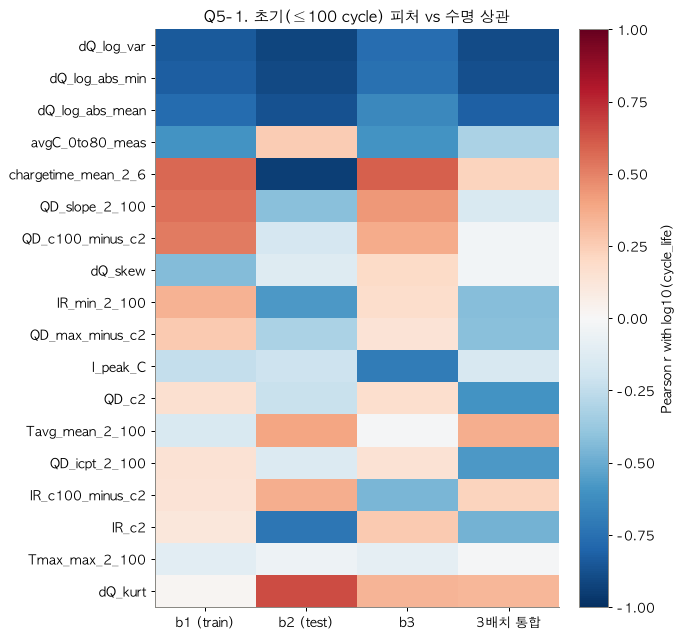

Pearson:
                       b1    b2    b3   all
dQ_log_var          -0.84 -0.92 -0.76 -0.90
dQ_log_abs_min      -0.82 -0.90 -0.74 -0.88
dQ_log_abs_mean     -0.77 -0.87 -0.65 -0.81
avgC_0to80_meas     -0.59  0.25 -0.60 -0.32
chargetime_mean_2_6  0.57 -0.94  0.60  0.23
QD_slope_2_100       0.55 -0.42  0.43 -0.15
QD_c100_minus_c2     0.52 -0.17  0.37 -0.03
dQ_skew             -0.43 -0.13  0.19 -0.03
IR_min_2_100         0.34 -0.57  0.17 -0.42
QD_max_minus_c2      0.26 -0.31  0.13 -0.42
I_peak_C            -0.24 -0.20 -0.70 -0.16
QD_c2                0.16 -0.23  0.17 -0.60
Tavg_mean_2_100     -0.16  0.39 -0.01  0.37
QD_icpt_2_100        0.15 -0.14  0.14 -0.57
IR_c100_minus_c2     0.14  0.36 -0.46  0.22
IR_c2                0.12 -0.72  0.27 -0.47
Tmax_max_2_100      -0.10 -0.05 -0.09 -0.01
dQ_kurt              0.02  0.65  0.34  0.33

Spearman:
                       b1    b2    b3   all
dQ_log_var          -0.83 -0.71 -0.80 -0.89
dQ_log_abs_min      -0.79 -0.66 -0.78 -0.88
dQ_log_abs_m

In [57]:
feats = ["dQ_log_var", "dQ_log_abs_min", "dQ_log_abs_mean", "dQ_skew", "dQ_kurt",
         "QD_c2", "QD_max_minus_c2", "QD_c100_minus_c2", "QD_slope_2_100", "QD_icpt_2_100",
         "IR_c2", "IR_min_2_100", "IR_c100_minus_c2", "Tavg_mean_2_100", "Tmax_max_2_100",
         "chargetime_mean_2_6", "avgC_0to80_meas", "I_peak_C"]
assert "cycle_life" not in feats and "logL" not in feats          # 누수 방지

# 배치별(b1, b2, b3)과 3배치 통합(all)에서 피처와 log10 수명의 상관 (빈 값은 쌍별로 제외)
groups = dict(list(clean.groupby("batch")) + [("all", clean)])
R = pd.DataFrame({b: g[feats].corrwith(g.logL) for b, g in groups.items()})
RS = pd.DataFrame({b: g[feats].corrwith(g.logL, method="spearman") for b, g in groups.items()})
R = R.loc[R.b1.abs().sort_values(ascending=False).index]         # Batch1 |r| 큰 순서

fig, ax = plt.subplots(figsize=(7.5, 7))
im = ax.imshow(R.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(4), ["b1 (train)", "b2 (test)", "b3", "3배치 통합"])
ax.set_yticks(range(len(R)), R.index)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Pearson r with log10(cycle_life)")
ax.set_title("Q5-1. 초기(≤100 cycle) 피처 vs 수명 상관")
plt.show()
print("Pearson:")
print(R.round(2))
print("\nSpearman:")
print(RS.loc[R.index].round(2))


**Q5-2** Batch1 피처끼리의 Pearson 상관: |r| > 0.8인 쌍, 최종 피처끼리 r

In [56]:
cand = ["dQ_log_var", "dQ_log_abs_min", "dQ_log_abs_mean", "dQ_skew", "dQ_kurt", "QD_c2", "QD_max_minus_c2",
        "QD_slope_2_100", "IR_c2", "IR_c100_minus_c2", "Tavg_mean_2_100", "chargetime_mean_2_6", "avgC_0to80_meas"]
C = clean[clean.batch == "b1"][cand].corr()     # Batch1(n=36) 후보 피처 13개끼리 Pearson r
pairs = []              # |r| > 0.8 = 사실상 같은 정보
for i in range(len(cand)):
    for j in range(i + 1, len(cand)):
        r = C.iloc[i, j]
        if abs(r) > 0.8:
            pairs.append((cand[i], cand[j], round(float(r), 2)))
print("|r|>0.8 피처 쌍:", pairs)
dq3 = ["dQ_log_var", "dQ_log_abs_min", "dQ_log_abs_mean"]
print(C.loc[dq3, dq3].round(2))                  # ΔQ 계열 3종끼리
print("최종 피처간의 상관 (Batch1): dQ_log_var vs avgC_0to80_meas r = %.2f" % C.loc["dQ_log_var", "avgC_0to80_meas"])

|r|>0.8 피처 쌍: [('dQ_log_var', 'dQ_log_abs_min', 1.0), ('dQ_log_var', 'dQ_log_abs_mean', 0.98), ('dQ_log_abs_min', 'dQ_log_abs_mean', 0.99), ('chargetime_mean_2_6', 'avgC_0to80_meas', -0.99)]
                 dQ_log_var  dQ_log_abs_min  dQ_log_abs_mean
dQ_log_var             1.00            1.00             0.98
dQ_log_abs_min         1.00            1.00             0.99
dQ_log_abs_mean        0.98            0.99             1.00
최종 피처간의 상관 (Batch1): dQ_log_var vs avgC_0to80_meas r = 0.64
